# Vector Field - Reactive Algorithms - Spring with Steam

## A Stream with a Spring

This one is going to have less visualizations than the first.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Define Constants

In [2]:
# 2. Define constants
def reset_constants():
    global x_start, y_start, x_end, y_end, quiver_step_size, angle, robot_offset
    global x_source, y_source, robot_1_start, robot_2_offset, robot_3_offset, robot_step_size
    global stop_simulation, flaggs
    
    x_start = y_start = 0
    x_end = y_end = 10
    quiver_step_size = 0.2

    x_source = 3 
    y_source = 5

    robot_1_start = [8,7.5]
    robot_2_offset = [0.5,0]
    robot_3_offset = [0,0.5]

    robot_step_size = 0.3
    angle = 0 # Needed for initialization for some reason
    robot_offset = 0.5 # Spacing for alignment
    stop_simulation = False
    flaggs = False

## 3. Define Flow Field

## 3. Define the Robot Cluster

## 3. Define Flows and Robot Movements

In [3]:
def vortex_stream(x, y, x_source, y_source):
    
    x_centre = x - x_source
    y_centre = y - y_source

    # Radial Distance from Centre
    r = np.sqrt(x_centre**2 + y_centre**2)

    # Calculate the angular component of the velocity
    v_theta = 1 / r 

    # Convert to cartesian coordinates
    u = v_theta * y_centre / r + np.ones_like(x) 
    v = -v_theta * x_centre / r 

    return u, v

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    
    # Establishing a Uniform Flow
    u = np.ones_like(x)  
    v = np.zeros_like(x) 
    
    # Adding the uniform flow to the spring source
    u = u + x_centre / dist**2
    v = v + y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v,u)  
    
    return mag, angle

def plot_robot_position(pos1,pos2,pos3):

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    
    
def max_flow_finder(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, robot_step_size, angle):
    if np.sign(slope_y)>0:
        pos1[1] += robot_step_size
        pos2[1] += robot_step_size
        pos3[1] += robot_step_size
    else:
        pos1[1] -= robot_step_size
        pos2[1] -= robot_step_size
        pos3[1] -= robot_step_size
    return pos1, pos2, pos3
    
def spring_finder(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, step_size, angle):
    
    angle = np.arctan2(slope_y,slope_x) #- np.pi/2
    
    
    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    return pos1, pos2, pos3

def fast_flow_aligned(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, step_size, angle):

    
    if np.sign(slope_y1)>0 and np.sign(slope_y2)>0:
        pos1[1] += step_size
        pos2[1] += step_size
        pos3[1] += step_size
    elif np.sign(slope_y1)<0 and np.sign(slope_y2)<0:
        pos1[1] -= step_size
        pos2[1] -= step_size
        pos3[1] -= step_size
    return pos1, pos2, pos3

def stagnation_finder(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, step_size, angle):
    
    global flaggs
    
    angle = np.arctan2(slope_y,slope_x)

    readings = [robot_readings(pos[0], pos[1], x_source, y_source) for pos in [pos1, pos2, pos3]]
    composites = [composite_vector(u, v) for u, v in readings]
   


    if (angle >0.2 ) or flaggs:
        
        print()
        composites = [(10 - comp[0], comp[1]) for comp in composites]
        slope_x = (composites[1][0] - composites[0][0])/ robot_2_offset[0]
        slope_y = (composites[2][0] - composites[0][0]) / robot_3_offset[1]
        angle = np.arctan2(slope_y,slope_x) + np.pi/2
        print(slope_x,slope_y, angle)
        pos1[0] += step_size*np.cos(angle)
        pos1[1] += step_size*np.sin(angle)
        pos2[0] += step_size*np.cos(angle)
        pos2[1] += step_size*np.sin(angle)
        pos3[0] += step_size*np.cos(angle)
        pos3[1] += step_size*np.sin(angle)
        flaggs = True
    
    else:
        angle -= np.pi/2
        print(angle)
        #angle = np.arctan2(slope_y,slope_x)
        pos1[0] += step_size*np.cos(angle)
        pos1[1] += step_size*np.sin(angle)
        pos2[0] += step_size*np.cos(angle)
        pos2[1] += step_size*np.sin(angle)
        pos3[0] += step_size*np.cos(angle)
        pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3


def initialize_vortex_field(x_start, x_end, quiver_step_size, y_start, y_end, x_source, y_source):
    x = np.arange(x_start, x_end, quiver_step_size)
    y = np.arange(y_start, y_end, quiver_step_size)
    X, Y = np.meshgrid(x, y)
    u, v = vortex_stream(X, Y, x_source, y_source)
    return x, y, u, v

def initialize_robots(robot_1_start, robot_2_offset, robot_3_offset):
    pos1 = robot_1_start
    pos2 = [(robot_1_start[0] + robot_2_offset[0]),(robot_1_start[1] + robot_2_offset[1])]
    pos3 = [(robot_1_start[0] + robot_3_offset[0]),(robot_1_start[1] + robot_3_offset[1])]
    angle = 0
    return pos1, pos2, pos3, angle

def alignment_step(robot_1_start, robot_offset, x_source, y_source):
    # Doing a rotation step prior to the main loop.

    pos1 = robot_1_start
    [u1, v1] = robot_readings(pos1[0],pos1[1], x_source, y_source)
    pos2 = [pos1[0] + robot_offset, pos1[1] + robot_offset]
    [u2, v2] = robot_readings(pos2[0],pos2[1], x_source, y_source)
    pos3 = [pos2[0] + robot_offset, pos2[1] + robot_offset]
    [u3, v3] = robot_readings(pos3[0],pos3[1], x_source, y_source)

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)

    angle = (angle1+angle2+angle3)/3 +np.pi/2

    pos1 = robot_1_start
    pos2 = [pos1[0] + robot_offset*np.cos(angle),pos1[1] + robot_offset*np.sin(angle)]
    pos3 = [pos2[0] + robot_offset*np.cos(angle),pos2[1] + robot_offset*np.sin(angle)]

    return pos1, pos2, pos3, angle


## Main Function

In [4]:
def execute_simulation(update_robot_position, title):
    # Initialize
    x, y, u, v = initialize_vortex_field(x_start, x_end, quiver_step_size, y_start, y_end, x_source, y_source)
    pos1, pos2, pos3, angle = initialize_robots(robot_1_start, robot_2_offset, robot_3_offset)
    print(' Initial Positions', pos1, pos2, pos3)
    # Initialize output Plot
    plt.figure(figsize=(6, 6))
    plot_robot_position(pos1, pos2, pos3)
    print(title)
    
    if title == 'Fast Flow Aligned':
        pos1, pos2, pos3, angle = alignment_step(robot_1_start, robot_offset, x_source, y_source)

    # Main
    for _ in range(1, 200):
        readings = [robot_readings(pos[0], pos[1], x_source, y_source) for pos in [pos1, pos2, pos3]]
        composites = [composite_vector(u, v) for u, v in readings]
        
        slope_x = (composites[1][0] - composites[0][0])/ robot_2_offset[0]
        slope_y = (composites[2][0] - composites[0][0]) / robot_3_offset[1] 
        slope_y1 = (composites[1][0] - composites[0][0]) / robot_2_offset[0]
        slope_y2 = (composites[2][0] - composites[1][0]) / (robot_3_offset[1] - robot_2_offset[1])
        
        #print(slope_y1)
        plot_robot_position(pos1, pos2, pos3)
       

        pos1, pos2, pos3 = update_robot_position(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, robot_step_size, angle)

        
    # Plot Outcome
    plt.quiver(x, y, u, v)
    plt.title(title)
    plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:10: RuntimeWarning: divide by zero encountered in divide
  v_theta = 1 / r
C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:13: RuntimeWarning: invalid value encountered in multiply
  u = v_theta * y_centre / r + np.ones_like(x)
C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:14: RuntimeWarning: invalid value encountered in multiply
  v = -v_theta * x_centre / r


 Initial Positions [8, 7.5] [8.5, 7.5] [8, 8.0]
Max Flow Finder


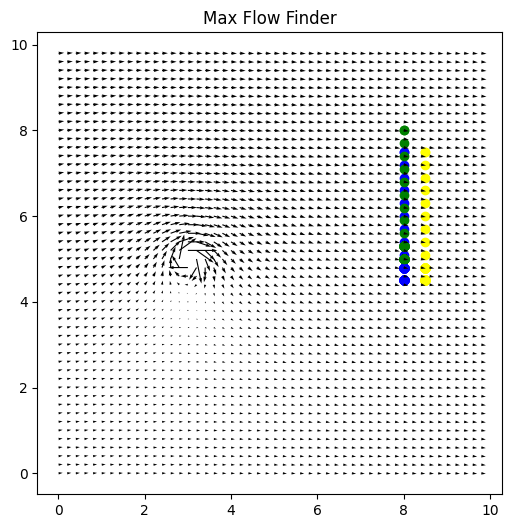

 Initial Positions [8, 7.5] [8.5, 7.5] [8, 8.0]
Spring Finder


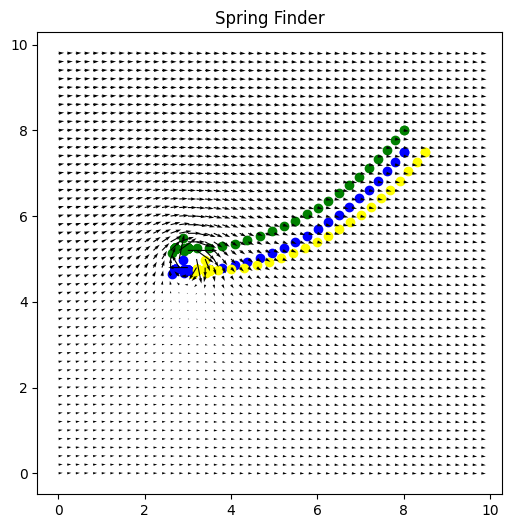

 Initial Positions [8, 7.5] [8.5, 7.5] [8, 8.0]
Fast Flow Aligned


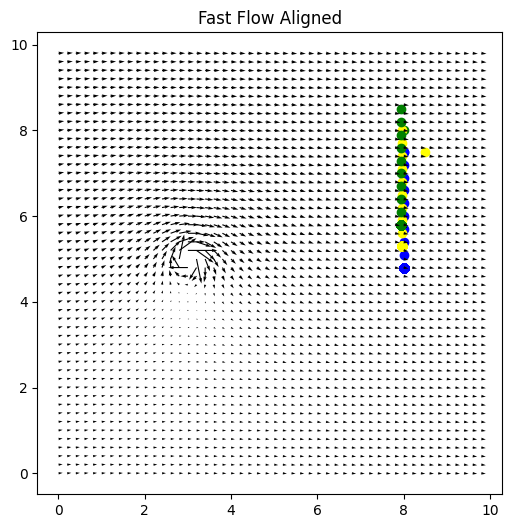

 Initial Positions [8, 7.5] [8.5, 7.5] [8, 8.0]
Stagnation Finder
-3.8255510360382585
-3.748404200090761
-3.6710621891848487
-3.5929852342887947
-3.513608901577943
-3.4323526635698776
-3.348635074158478
-3.2618993369113136
-3.171653464398571
-3.077528554391064
-2.97935573393974
-2.8772556636580457
-2.771723786044337
-2.6636825646860007
-2.5544665228013272
-2.4457171103375144
-2.3391956371811964
-2.2365604065424183
-2.1391732044867395
-2.0479842525309864
-1.963502707401899
-1.8858136131862362
-1.8145544357744088
-1.7486679670811405
-1.6855714427710786
-1.6211960219340356
-1.5763530350115587
-1.5531433961683636
-1.4239195929481836

-0.9124129503675711 -0.3148187274769221 -1.2385472631220869

-0.544254446618897 -0.3354086980009292 -1.0184980640069337

-0.3470610586780829 -0.3375200874911144 -0.7993342081907491

-0.2270851983416513 -0.32469505974384916 -0.6103096684904985

-0.147491755600214 -0.3000972625277356 -0.45680828116363736

-0.09198742172035779 -0.26863533749558144 -0.329910503857


0.06652974966686642 -0.02304386771235656 1.237359572856732

0.06790974616399481 -0.010490348207092381 1.4175328915704999

0.06896967675948673 0.0014855812957499381 1.592332626246043

0.06967790685601116 0.013167035988686848 1.7575640000392736

0.06993654762468893 0.024768607804354303 1.9111708184126752

0.06959105513330854 0.036435740704646946 2.0531211078744676

0.06843647436714662 0.04824342155749406 2.1848282164251085

0.0662200214310893 0.060194704353286 2.308567439333652

0.06264103757871098 0.07221987745114333 2.427102954056932

0.057349361143078426 0.08417812754054665 2.543537296259379

0.049941826895675945 0.0958648593664222 2.661317418699833

0.03995381113565344 0.10702900269960836 2.784314174384621

0.026837717386449356 0.11740547711591276 2.916863840984907

0.009911410788916442 0.12676842068708183 3.0635662129660206

-0.011756082446403582 0.13501062788173357 3.228448815589389

-0.03958248731342806 0.1422523421610471 3.4129828901482853

-0.07594869212791622 0.148972432336588

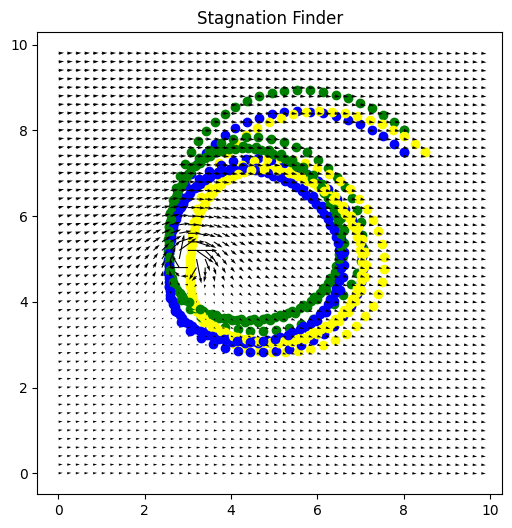

In [5]:
# 5. Execute the simulations
reset_constants()
execute_simulation(max_flow_finder, 'Max Flow Finder')
reset_constants()
execute_simulation(spring_finder, 'Spring Finder')
reset_constants()
execute_simulation(fast_flow_aligned, 'Fast Flow Aligned')
reset_constants()
execute_simulation(stagnation_finder, 'Stagnation Finder')


C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:10: RuntimeWarning: divide by zero encountered in divide
  v_theta = 1 / r
C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:13: RuntimeWarning: invalid value encountered in multiply
  u = v_theta * y_centre / r + np.ones_like(x)
C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:14: RuntimeWarning: invalid value encountered in multiply
  v = -v_theta * x_centre / r


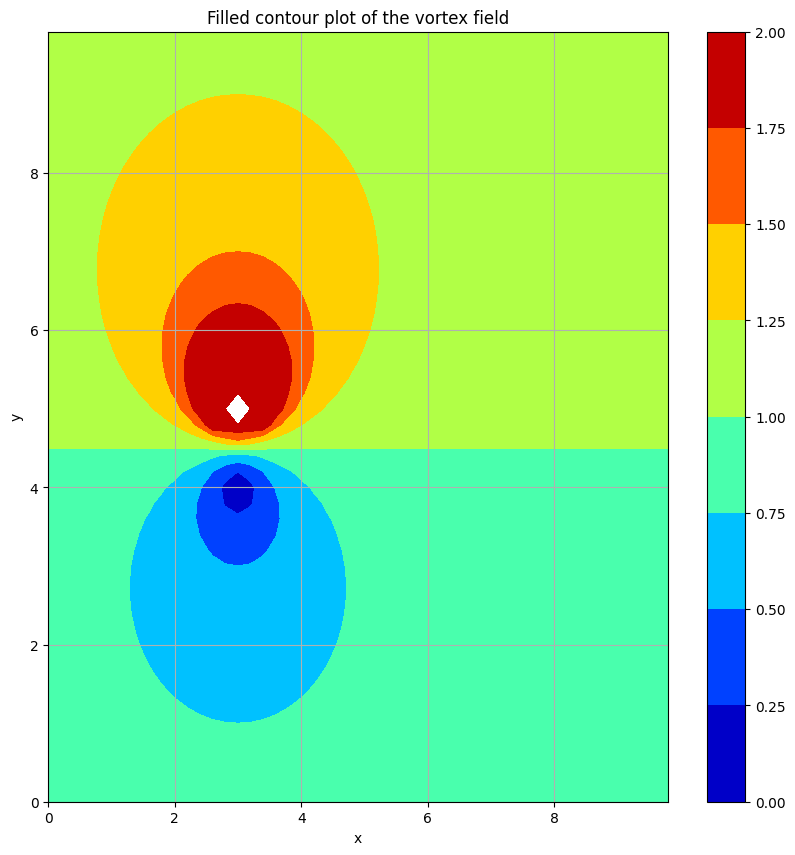

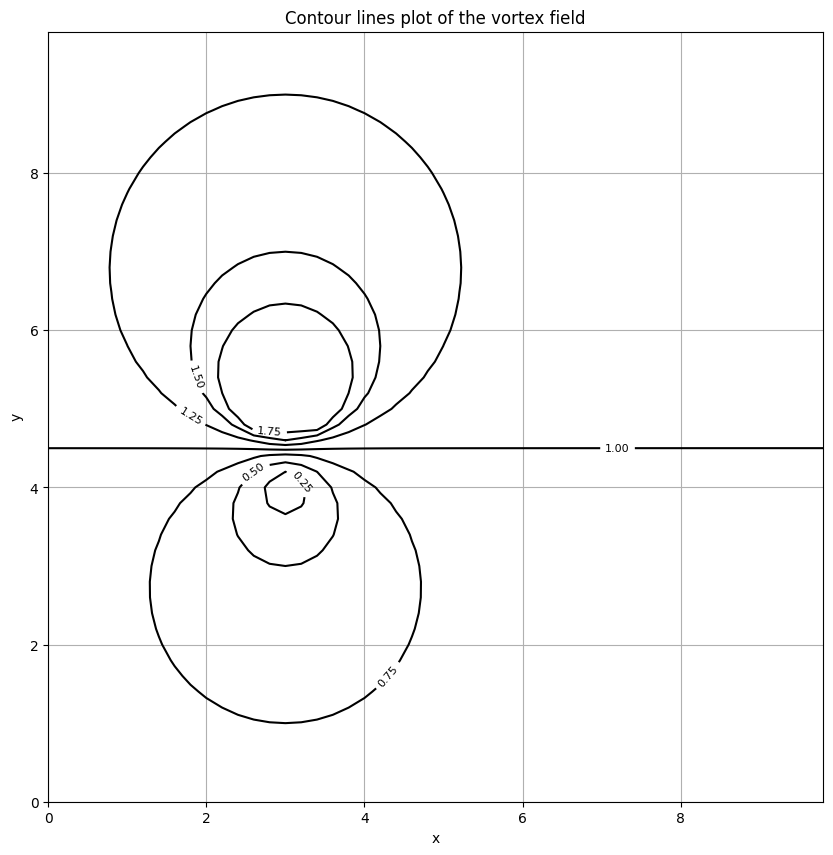

In [6]:
import numpy as np

def mag_plot(x, y, u, v):
    # Generate the magnitude of the vortex field and limit to max value of 3
    mag_uv = np.sqrt(u**2 + v**2)
    mag_uv = np.where(mag_uv > 2, 2, mag_uv)

    # Generate the filled contour plot with a colorbar
    plt.figure(figsize=(10,10))
    filled_contour = plt.contourf(x, y, mag_uv, cmap='jet') 
    plt.colorbar(filled_contour)
    plt.title('Filled contour plot of the vortex field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()
    
    # Generate the contour line plot
    plt.figure(figsize=(10,10))
    line_contour = plt.contour(x, y, mag_uv, colors='black') 
    plt.clabel(line_contour, inline=True, fontsize=8)
    plt.title('Contour lines plot of the vortex field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

# Your initialization and calculation of the vortex field
x_start = 0
x_end = 10
quiver_step_size = 0.2
y_start = 0
y_end = 10
x_source = 3 
y_source = 5

x, y, u, v = initialize_vortex_field(x_start, x_end, quiver_step_size, y_start, y_end, x_source, y_source)

# Call the plot function
mag_plot(x, y, u, v)


C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:10: RuntimeWarning: divide by zero encountered in divide
  v_theta = 1 / r
C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:13: RuntimeWarning: invalid value encountered in multiply
  u = v_theta * y_centre / r + np.ones_like(x)
C:\Users\chris\AppData\Local\Temp\ipykernel_57376\130686283.py:14: RuntimeWarning: invalid value encountered in multiply
  v = -v_theta * x_centre / r


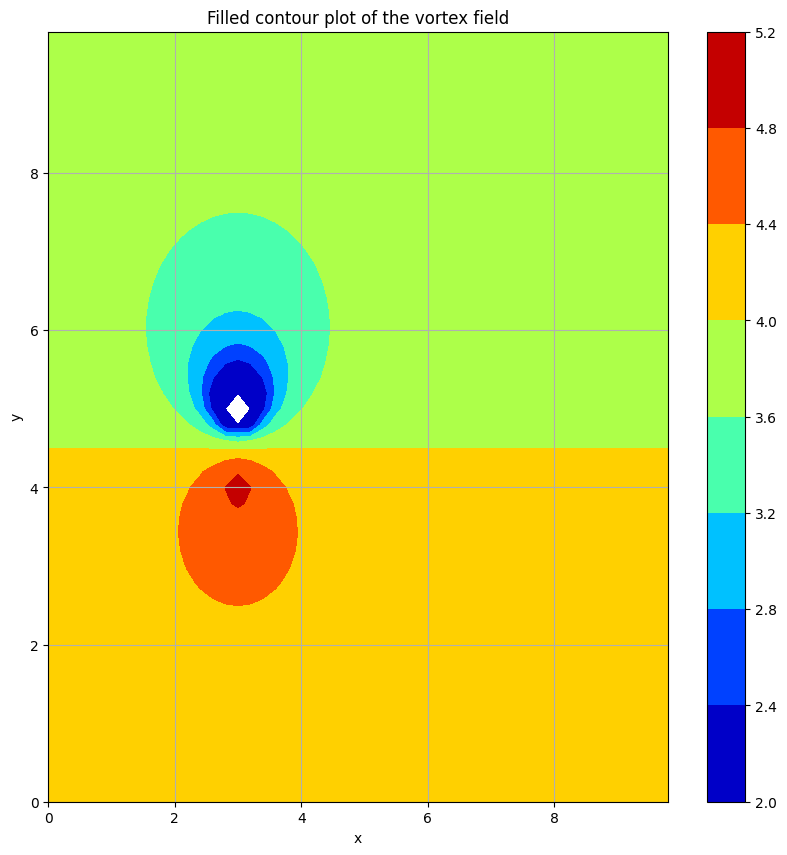

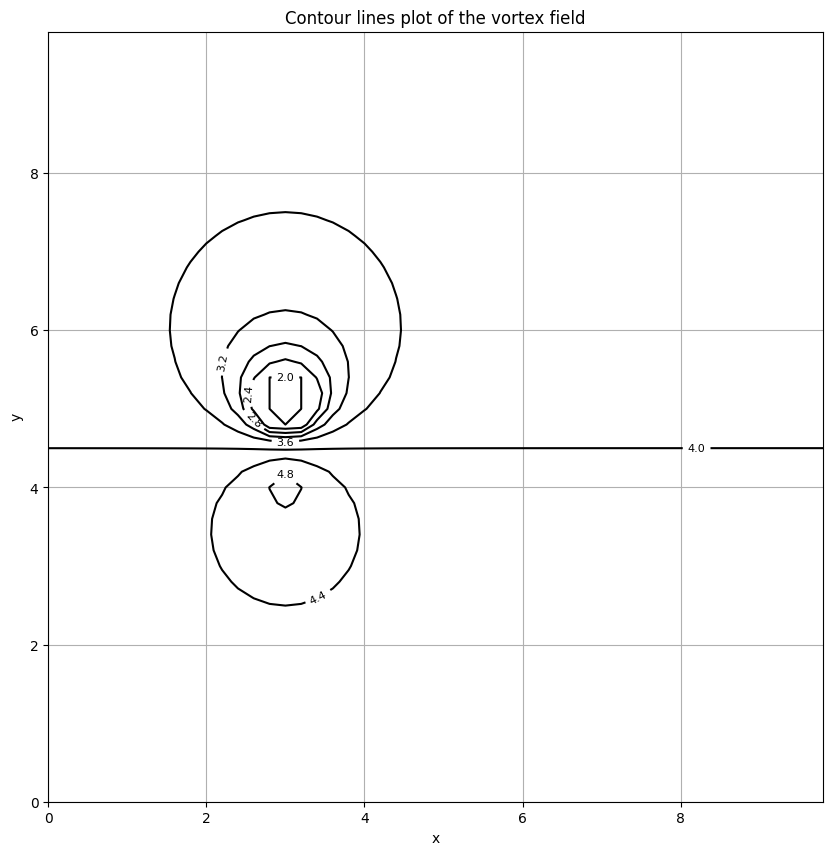

In [7]:
import numpy as np

def plot_vortex_field(x, y, u, v):
    # Generate the magnitude of the vortex field and limit to max value of 3
    mag_uv = np.sqrt(u**2 + v**2)
    mag_uv = 5 - mag_uv
    mag_uv = np.where(mag_uv < 2, 2, mag_uv)

    # Generate the filled contour plot with a colorbar
    plt.figure(figsize=(10,10))
    filled_contour = plt.contourf(x, y, mag_uv, cmap='jet') 
    plt.colorbar(filled_contour)
    plt.title('Filled contour plot of the vortex field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()
    
    # Generate the contour line plot
    plt.figure(figsize=(10,10))
    line_contour = plt.contour(x, y, mag_uv, colors='black') 
    plt.clabel(line_contour, inline=True, fontsize=8)
    plt.title('Contour lines plot of the vortex field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

# Your initialization and calculation of the vortex field
x_start = 0
x_end = 10
quiver_step_size = 0.2
y_start = 0
y_end = 10
x_source = 3 
y_source = 5

x, y, u, v = initialize_vortex_field(x_start, x_end, quiver_step_size, y_start, y_end, x_source, y_source)

# Call the plot function
plot_vortex_field(x, y, u, v)
